# Assignment 8: Transformers

---

## Text-to-Text for Summarization

Transformers are powerful attention-based models that have great power for generalization.
Googles T5 is a popular and recent Text-to-Text transformer.
A cool blog post about it can be found on Googles [AI.blog](https://ai.googleblog.com/2020/02/exploring-transfer-learning-with-t5.html).
T5 is supposedly able to handle all kinds of NLP tasks like summarization, question answering, and text classification.
The [paper](https://arxiv.org/abs/1910.10683) sheds some light on what they actually wanted to achieve.
In our exercise we want to answer the question if we can use a pre-trained transformer model to summarize abstracts of our theses so they come close to their original titles?
We will try this task in two ways: *out of the box* and *fine-tuning* on our dataset.
Both should summarize the abstract to a thesis title.

## Data

Download and use the theses.csv dataset from the Supplemental Materials in the Files section of our Microsoft Teams group.
This dataset contains approximately 3,000 thesis topics chosen by students in the past. Each entry includes a thesis title along with the corresponding abstract in the Abstract column.
Note that not all entries include abstracts, so some filtering steps will be necessary.

## Basic Setup

First, you will need to download a German T5 model from this [link](https://huggingface.co/ml6team/mt5-small-german-finetune-mlsum)
You can either clone the model repository or, preferably, download it directly using the [Transformers](https://huggingface.co/docs/transformers/index) library (recommended!).
To get started, install the required libraries (you will need the sentencepiece tokenizer for this specific transformer model).
Then, use the following code to load the tokenizer and model:
```python
# pip install transformers sentencepiece

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained("ml6team/mt5-small-german-finetune-mlsum")
model = AutoModelForSeq2SeqLM.from_pretrained("ml6team/mt5-small-german-finetune-mlsum")
```

*In this Jupyter Notebook, we will provide the steps to solve this task and give hints via functions & comments. However, code modifications (e.g., function naming, arguments) and implementation of additional helper functions & classes are allowed. The code aims to help you get started.*

---

In [1]:
# Dependencies
import os
import tqdm
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.model_selection import train_test_split

# Torch stuff
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# Transformers stuff
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM
from transformers import T5ForConditionalGeneration

In [2]:
# For readability
warnings.filterwarnings("ignore")

### Prepare the Data

1.1 As always... spend some time on preparing the dataset. It may be helpful to lower-case the data and to filter for German titles.

1.2 Remove very short titles, you can evaluate by a metric, e.g. len(abstract_words) / len(thesis title words). Furthermore, check the suitability of the model (e.g., max source / target lengths).

1.3 Tokenize properly and implement helper classes / functions which handles your tokenized data with respect to your model and task!

In [3]:
### TODO: 1.1 & 1.2 Implement dataset loading, preprocessing, and filtering

def load_theses_dataset(filepath):
    """Loads all theses instances and returns them as a dataframe."""

    return pd.read_csv(filepath, header=0, sep=";")


def preprocess(dataframe, min_abstract_length=50, limit_title_length=None):
    """Preprocesses and filters the given theses titles for further use."""

    dataframe = dataframe.copy()

    # Filter out outliers if required
    dataframe["Abstract"] = dataframe["Abstract"].fillna(value="")
    dataframe["abstract_length"] = dataframe["Abstract"].apply(lambda x: len(x.split()))
    dataframe = dataframe[dataframe["abstract_length"] >= min_abstract_length]

    dataframe["title_length"] = dataframe["Titel"].apply(lambda x: len(x.split()))
    if limit_title_length:
        dataframe = dataframe[dataframe["title_length"].between(limit_title_length[0], limit_title_length[1])]

    # Some basic preprocessing
    dataframe["Abstract"] = dataframe["Abstract"].apply(lambda x: x.replace("\n", " "))
    dataframe["Titel"] = dataframe["Titel"].apply(lambda x: x.replace("\n", " "))

    # Reset index of dataframe
    dataframe = dataframe.reset_index(drop=True)

    # Filter for german thesis
    dataframe = dataframe[dataframe["Sprache"] == "DE"]

    return dataframe

In [4]:
### TODO: 1.3 Implement pytorch dataset class for fine-tuning task

class ThesisDataset(Dataset):
    def __init__(self, df, tokenizer, max_input_len, max_output_len):
        self.tokenizer = tokenizer
        self.source_len = max_input_len
        self.summ_len = max_output_len
        self.Titel = df.Titel

        # T5 requires us to prepend the task
        self.Abstract = 'summarize: ' + df.Abstract

    def __len__(self):
        return len(self.Titel)

    def __getitem__(self, index):
        abstract = str(self.Abstract.iloc[index])
        title = str(self.Titel.iloc[index])

        # use tokenizer.batch_encode_plus to also get the masking
        source_tok = self.tokenizer.batch_encode_plus([abstract],
                                                      max_length=self.source_len,
                                                      truncation=True,
                                                      pad_to_max_length=True,
                                                      return_tensors='pt')
        label_tok = self.tokenizer.batch_encode_plus([title],
                                                     max_length=self.summ_len,
                                                     truncation=True,
                                                     pad_to_max_length=True,
                                                     return_tensors='pt')

        input_ids = source_tok['input_ids'].squeeze()
        input_mask = source_tok['attention_mask'].squeeze()
        label_ids = label_tok['input_ids'].squeeze()
        label_mask = label_tok['attention_mask'].squeeze()

        return {
            'input_ids': input_ids.to(dtype=torch.long),
            'input_mask': input_mask.to(dtype=torch.long),
            'label_ids': label_ids.to(dtype=torch.long),
            'label_mask': label_mask.to(dtype=torch.long)
        }

In [5]:
# Load and preprocess dataset
dataframe = load_theses_dataset("data/theses2022.csv")
dataframe = preprocess(dataframe)

# Check number of samples
print("Number of samples:", len(dataframe))
dataframe[["Titel", "Abstract"]].head()

Number of samples: 753


,Titel,Abstract
0,Untersuchung und Konzeption des Einsatzes von ...,Im Fokus dieser Arbeit steht der Einsatz von C...
1,Objekterkennung mit Convolutional Neural Netwo...,Im Rahmen dieser Masterthesis wird die Klassif...
2,Analyse von Technologien zur Desktopbereitstel...,Viele Unternehmen verfügen über etablierte Des...
3,Konzeption und Implementierung einer mobilen A...,"Ziel der Masterarbeit ist es, eine mobile Anwe..."
4,Konzeptionierung und Realisierung einer Anwend...,Das Ziel dieser Bachelorarbeit ist die Konzept...


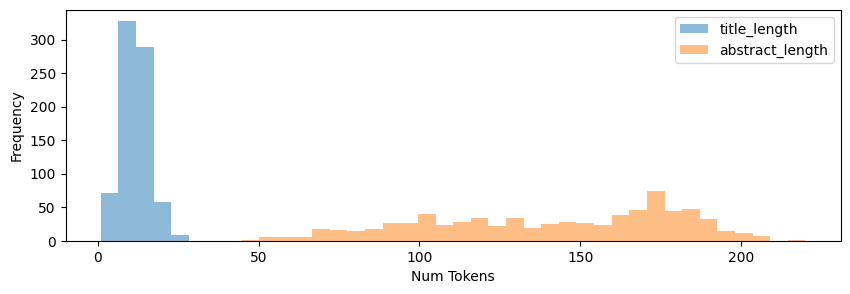

In [6]:
# Let's check some stats about the abstract and title lengths
fig, ax = plt.subplots(figsize=(10, 3))
dataframe[["title_length", "abstract_length"]].plot.hist(bins=40, alpha=0.5, ax=ax)
ax.set_xlabel("Num Tokens")
ax.set_ylabel("Frequency")
plt.show()

In [7]:
# Train-test split as we want to compare generations later

SEED = 42

train_dataframe, test_dataframe = train_test_split(dataframe, test_size=50, random_state=SEED)
print("Number of samples (train):", len(train_dataframe))
print("Number of samples (test):", len(test_dataframe))

# Sample a few examples for qualitative comparison

NUM_SAMPLES = 5
test_samples = test_dataframe.sample(n=NUM_SAMPLES, replace=False, random_state=SEED)

Number of samples (train): 703
Number of samples (test): 50


### Task 1: Out of the box

Let's see if we can put this to use in our thesis example from the previous exercises.
Follow the [instructions](https://huggingface.co/ozcangundes/mt5-small-turkish-summarization) for a Turkish summarization model
on [Hugging Face](https://huggingface.co/).
The steps should work the same for our German task.
Implement some summarization and check qualitatively if you're content with the results.
When generating, check some of the model parameters like **beamsize**, **repetition_penalty**, **length_penalty** and play around with them.
**What do those parameters mean and how do they influence the output?**

2.1 Set up the model and tokenizer with the Transformers library and download / load the pre-trained model weights of your choice!

2.2 Implement a method for summary generation including preparation steps and configuration of model parameters. You need to consider `tokenizer.decode` to map the ids back to string tokens.

2.3 Use the pre-trained model and your summary generation method to generate some thesis titles and (qualitatively) compare them to the reference titles. What generation parameters did you choose?

In [8]:
### TODO: 2.1 Construct model and load pre-trained weights

HF_MODEL_ID = "ml6team/mt5-small-german-finetune-mlsum"
tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_ID)
model = AutoModelForSeq2SeqLM.from_pretrained(HF_MODEL_ID)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [9]:
### TODO: 2.2 Implement method for summary generation with "zero-shot"

def generate_summary(model, abstract, num_beams, repetition_penalty,
                     length_penalty, early_stopping, max_output_length):

    # Prepare data with tokenization
    source_encoding = tokenizer(
        abstract,
        max_length=512,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        add_special_tokens=True,
        return_tensors="pt"
    )

    # Use provided "generate" function for convenience
    # Of course, you can also implement the generation...
    generated_ids = model.generate(
        input_ids=source_encoding["input_ids"],
        attention_mask=source_encoding["attention_mask"],
        num_beams=num_beams,
        max_length=max_output_length,
        repetition_penalty=repetition_penalty,
        length_penalty=length_penalty,
        early_stopping=early_stopping,
        use_cache=True
    )

    # Map ids back to strings using tokenizer.decode and return summary (i.e., title)
    preds = [
        tokenizer.decode(
            gen_id, skip_special_tokens=True, clean_up_tokenization_spaces=True
        ) for gen_id in generated_ids
    ]

    return "".join(preds)

In [10]:
### TODO: 2.3 Qualitatively assess summary generation and experiment with configuration

# Configuration of summary generation

num_beams = 2
repetition_penalty = 1.0
length_penalty = 2.0
max_output_length = 80 # Notice: tokens not words...
early_stopping = True


# Sample from dataset, using abstracts as input to generate short summary (i.e., title)

for i, row in test_samples.iterrows():
    # Get input and output values
    abstract = row.Abstract
    reference = row.Titel

    generated = generate_summary(model, "summarize: " + str(abstract),
                                 num_beams, repetition_penalty, length_penalty, early_stopping,
                                 max_output_length)

    display(HTML(f"""<table>
    <tr><td>abstract:</td><td>{abstract}</td></tr>
    <tr><td>generated:</td><td>{generated}</td></tr>
    <tr><td>reference:</td><td>{reference}</td></tr>
    </table>
    """))

abstract:,"Das Ziel der vorliegenden Arbeit ist es zu beantworten, welche Reifegradmodelle für dieSoftwareentwicklung existieren. Mit dem Ergebnis dieser Forschungsfrage wird beleuchtet,welche Unterschiede und Gemeinsamkeiten die identifizierten Reifegradmodelle besitzen undwelches Reifegradmodell für welchen Anwendungsfall in der Praxis geeignet ist. Um dieForschungsfragen zu beantworten wurde eine systematische Literaturrecherche umgesetzt.Anschlie?end wurde eine tiefere, qualitative Analyse der identifizierten Reifegradmodelledurchgeführt, die sich in eine methodische Analyse und eine Inhaltsanalyse aufteilt. MitHilfe der Literaturrecherche wurden 19 Reifegradmodelle für die Softwareentwicklung identifiziert.Anhand der qualitativen Analyse konnten neun Unterschiede und Gemeinsamkeitenzwischen den identifizierten Reifegradmodellen gefunden werden. Darüber hinaus wurdefür mehrere Anwendungf?lle in fünf verschiedenen Anwendungsbereichen geeignete Reifegradmodellefür Unternehmen identifiziert. Bei der Beantwortung der Forschungsfragen hatsich herausgestellt, dass für Unternehmen kein allgemeingültiges Reifegradmodell empfohlenwerden kann. Die Wahl des Reifegradmodells sollte von dem konkreten Anwendungsfallabh?ngig gemacht werden."
generated:,"Das Ziel der vorliegenden Arbeit ist es zu beantworten, welche Reifegradmodelle für dieSoftwareentwicklung existieren. Mit dem Ergebnis dieser Forschungsfrage wird beleuchtet,welche Unterschiede und Gemeinsamkeiten die identifizierten Reifegradmodelle besitzen undwelches Reifegradmodell für welchen Anwendungsfall in der Praxis"
reference:,Analyse und Bewertung von Reifegradmodellen für die Softwareentwicklung


abstract:,"Um die Ehre des Titels Kulturhauptstadt Europas 2025 bemüht sich zurzeit die Stadt Nürnberg. Da im Jahr 2025 eine deutsche Stadt den Titel erhält, nutzt Nürnberg die Chance und fokussiert in der Bewerbung verschiedene Themenbereiche. Ein Bereich umfasst die Themen ""Arbeit, Lernen und Spiel"". In diesem Zusammenhang ist Gamification ein passender Begriff. Dieses Wort tritt in der heutigen Zeit vermehrt auf und wird im Rahmen unterschiedlichster Kontexte verwendet, da die Einbindung spielerischer Elemente in spielfremden Prozessen vielseitig anwendbar ist. Somit stellt sich im Zusammenhang der Kulturhauptstadtbewerbung mit dem beinhalteten Themenbereich die Frage, inwieweit Gamification im Rahmen der Stadtentwicklung eingesetzt werden kann. Die Komplexität der Frage wurde in einzelnen Teilen beantwortet. Einleitend ist eine allgemeine Verständnisvermittlung des bestehenden Kontextes ""Gamification innerhalb der Stadtentwicklung"" gegeben. Auf Basis eines einheitlichen Verständnisses wurden aus einer Vielfalt von Gamificationkonzepten unterschiedliche Konzepte analysiert. Da innerhalb der analysierten Gamificationkonzepte das Potential für eine Übertragung auf die Stadt Nürnberg erkennbar war, wurden die Bedürfnisse verschiedener Ämter bzw. Einrichtungen Nürnbergs ermittelt. Diese Erkenntnisgewinnung diente der Erstellung individueller Konzepte für Einrichtungen und Ämter der Stadt Nürnberg, welche die Stadtentwicklung und zudem die Kulturhauptstadtbewerbung unterstützen können."
generated:,"Da im Jahr 2025 eine deutsche Stadt den Titel erhält, nutzt Nürnberg die Chance und fokussiert in der Bewerbung verschiedene Themenbereiche. Ein Bereich umfasst die Themen ""Arbeit, Lernen und Spiel""."
reference:,Entwicklung und Analyse von Gamificationkonzepten als Beitrag zur Stadtentwicklung


abstract:,"In dieser Arbeit wurde eine mobile Anwendung zur Klassifizierung von Produkten der Dentalbranche implementiert. Hierzu kamen Convolution Neural Networks zum Einsatz, welche am Endgerät selbst ausgeführt wurden. Zur Umsetzung des Klassifikators wurden Lern-, Validierungs- und Teststichproben für 100 verschiedene Produkte erstellt. Bei der Wahl der Produkte wurden verschiedene optisch ähnliche Produkte berücksichtigt. Zudem wurden zwei Ansätze verglichen: Ein selbst erstelltes CNN mit 8 Schichten, sowie ein auf den ImageNet-Datensatz vortrainiertes Inception-V3-Netz. Die höchste Erkennungsrate von 96,51 % konnte mit 50 Stichproben pro Klasse für das Inception-V3-Netz erzielt werden. Des Weiteren wurde eine Auswirkung der Stichprobengröße auf die Erkennungsrate untersucht. Eine Einschränkung für den Klassifikator stellten Produkte dar, welche sich lediglich anhand leichter Farbvariationen voneinander unterschieden. In diesen Fällen empfiehlt sich eine manuelle Auswahl des Farbtons durch den Anwender. Je nach Endgerät war ein durchschnittlicher Zeitaufwand von 0,73 s bis 2,04 s für die Klassifikation nötig."
generated:,In dieser Arbeit wurde eine mobile Anwendung zur Klassifizierung von Produkten der Dentalbranche implementiert. Hierzu kamen Convolution Neural Networks zum Einsatz.
reference:,Entwicklung einer mobilen Anwendung zur Erkennung und Suche von Produkten mittels künstlicher neuronaler Netze


abstract:,"Risiken besitzen eine ambivalente Bedeutung für Unternehmen, da sie einerseits durch die verbundenen Chancen den Fortschrittbestand sichern und andererseits im Schadensfall unter Umständen die Unternehmensexistenz gefährden. Die IT-Lösungsbranche steht neben den alltäglichen Unternehmensrisiken durch Trends wie Cloud Computing unter steigendem Wettbewerbs- bzw. Preisdruck. Die Arbeit hat die Untersuchung der Auswirkungen der aktuellen Entwicklungen auf Risikomanagementprozesse bei IT-Lösungsanbietern zum Ziel. Der Fokus liegt dabei auf dem Angebotsprozess. Zentrale Fragestellung ist, ob und ferner wie bei IT-Lösungsanbietern der Umgang mit Risikofaktoren durch die Marktsituation beeinflusst wird. Die Untersuchung im Rahmen der Arbeit erfolgt in Kooperation mit der DXC Technology Group durch einen ethnographischen Ansatz und stellt fest, dass das in den Angebotsprozess integrierte Risikomanagement insbesondere durch die Neufassung der Delegation of Authority zukunftsweisend implementiert ist. Nichtsdestotrotz lassen die Erkenntnisse insbesondere im Hinblick auf die Erfassung unscharfer Risikofaktoren erkennen. Die Arbeit schlägt ein in den Angebotsprozess integriertes regelbasiertes Fuzzy-Expertensystem zur Risikobeurteilung und weiterhin zur Entscheidungsunterstützung hinsichtlich Verkaufstransaktionen vor."
generated:,Die Arbeit hat die Untersuchung der Auswirkungen der aktuellen Entwicklungen auf Risikomanagementprozesse bei IT-Lösungsanbietern zum Ziel. Der Fokus liegt dabei auf dem Angebotsprozess.
reference:,Risikomanagement in der IT-Dienstleistungsbranche im Kontext der aktuellen Marktsituation


abstract:,"Aufgrund des schnellen Wachstums und somit auch steigender Mitarbeiterzahl vieler Unternehmen der Softwareentwicklung benötigen diese eine Build-Infrastruktur, die dynamisch auf die steigende Last reagieren kann. Da die Auslieferung der Software von der Build-Infrastruktur abhängig ist, stellt dies einen essenziellen Aspekt der Wertschöpfungskette jedes Softwareentwicklungsunternehmen dar.Oft ist eine Build-Infrastruktur mit statischen Kapazitäten vorhanden, die unflexibel bezüglich Strukturänderungen und steigender Nutzerzahl ist. Im Kontext der Bachelorarbeit wird eine Infrastruktur mit ca. 1000 Nutzern und 5000 täglichen Builds betrachtet. Bei steigender Nutzerzahl ist manueller Personaleinsatz notwendig.Ziel der Arbeit ist passende architektonische Prinzipien zu ermitteln und eine Lösung zu gestalten, wie am Markt verfügbare Buildtechnologien zu einer flexiblen, dynamischen Infrastruktur verbaut werden können, die sowohl hinsichtlich Last als auch geänderter Anforderungen flexibel ist.Das Ergebnis wird ein Kriterienkatalog mit praxisnahem Anwendungsbeispiel sein, in dem sich alle wichtigen Aspekte und Eigenschaften hinsichtlich der oben genannten Zielsetzung der verschiedenen Technologien befinden.Die ermittelten Prinzipien werden mittels Gestaltung eines Konzepts praxisnah am Fallbeispiel des Unternehmens DATEV eG dargestellt. Die Konzeptionierung der Umsetzung dient zur späteren Validierung im realen Umfeld."
generated:,Die neue Build-Infrastruktur stellt einen essenziellen Aspekt der Wertschöpfungskette jedes Unternehmen dar.
reference:,Evaluation von skalierbaren Technologien für Build-Infrastrukturen in großen IT-Unternehmen und Konzeptionierung der Umsetzung am Fallbeispiel der DATEV eG


### Task 2: Fine-tuning
The big strength of those huge transformer model is that they can be fine-tuned on specific tasks.
So lets try that for our ***abstract to thesis title*** summarization.
Implement transfer learning of the model (e.g., mt5-small) you used in the previous task.
and fine-tune the model on our dataset (input abstracts -> output titles).
After fine-tuning try out the summarization and evaluate qualitatively again.
Check the [documentation](https://huggingface.co/transformers/model_doc/t5.html) for what you need to do.
This [notebook](https://github.com/abhimishra91/transformers-tutorials/blob/master/transformers_summarization_wandb.ipynb) might also come in handy.

3.1 As you could see, the title quality is pretty much hit-or-miss. Let's use transfer learning and fine-tune the pre-trained model to our title generation task. You can implement the training steps by yourself or use the [Trainer](https://huggingface.co/docs/transformers/training#trainer) of [Transformers](https://huggingface.co/docs/transformers/index).

3.2 Fine-tune the pre-trained model on your dataset, you might need `T5ForConditionalGeneration` for the training steps. Subsequently, (qualitatively) evaluate the results on the same entries used in the previous task. Can you see any improvements compared to the *out of the box* summarization?

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using available device:", device)

Using available device: cuda


In [12]:
### TODO: 3.1 Implement fine-tuning of pre-trained transformer model

# For each batch in the data loader, compute the forward pass, loss and
# backward pass

def train(epoch, tokenizer, model, device, dataloader, optimizer):
    model.train()

    count = 0
    for data in tqdm.notebook.tqdm(dataloader, desc=f"Train epoch {epoch}"):
        y = data['label_ids'].to(device, dtype=torch.long)
        y_ids = y[:, :-1].contiguous()
        lm_labels = y[:, 1:].clone().detach()

        # set the padding symbols to -100 to be ignored by torch
        lm_labels[y[:, 1:] == tokenizer.pad_token_id] = -100

        inputs = data['input_ids'].to(device, dtype=torch.long)
        mask = data['input_mask'].to(device, dtype=torch.long)

        # compute forward pass
        outputs = model(input_ids=inputs, attention_mask=mask,
                        decoder_input_ids=y_ids, labels=lm_labels)

        loss = outputs[0]

        if count % 10 == 0:
            print({"Training Loss": loss.item()})

        # reset optimizer, do backwards pass and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

    print(f'Epoch: {epoch}, Loss:  {loss.item()}')


In [13]:
### TODO: 3.2 Fine-tune your transformer model on the thesis train dataset

# Configuration of training

batch_size_train = 8
batch_size_val = 4

max_input_len = 512
max_output_len = 120

# Set random seeds and deterministic pytorch for reproducibility

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

# Creating the Training and Validation dataset for further creation of Dataloader

train_dataset = ThesisDataset(train_dataframe, tokenizer, max_input_len, max_output_len)
val_dataset = ThesisDataset(test_dataframe, tokenizer, max_input_len, max_output_len)

# Creating dataloaders for training and validation

train_dataloader = DataLoader(train_dataset, shuffle=True, num_workers=0, batch_size=batch_size_train)

# We just showcase a small example with qualitative evaluation;
# you can use some kind of validation dataset to select best checkpoint, hyper-parameters, etc.
# val_dataloader = DataLoader(val_dataset, shuffle=False, num_workers=0, batch_size=batch_size_val)

In [14]:
# For fine-tuning, we'll load it explicitly as a T5ForConditionalGeneration;
# the tokenizer will be the same

EPOCHS = 3
LEARNING_RATE = 1e-4

model = T5ForConditionalGeneration.from_pretrained(HF_MODEL_ID)
model = model.to(device)

optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

# Fine-tune the pre-trained transformer model on the thesis train dataset

for epoch in range(EPOCHS):
    # Call the training routine from above
    train(epoch+1, tokenizer, model, device, train_dataloader, optimizer)

# You might want to save the fine-tuned model weights
OUR_MODEL_DIR = os.path.join("./data/mt5-fine-tuned")
os.makedirs(OUR_MODEL_DIR, exist_ok=True)
model.save_pretrained(OUR_MODEL_DIR)

Train epoch 1:   0%|          | 0/88 [00:00<?, ?it/s]

{'Training Loss': 5.130557537078857}
{'Training Loss': 3.9734926223754883}
{'Training Loss': 3.076996326446533}
{'Training Loss': 3.449763774871826}
{'Training Loss': 3.4030861854553223}
{'Training Loss': 3.3150460720062256}
{'Training Loss': 4.09520149230957}
{'Training Loss': 3.779878854751587}
{'Training Loss': 3.3443875312805176}
Epoch: 1, Loss:  2.937187910079956


Train epoch 2:   0%|          | 0/88 [00:00<?, ?it/s]

{'Training Loss': 3.9693737030029297}
{'Training Loss': 2.9338488578796387}
{'Training Loss': 2.9024579524993896}
{'Training Loss': 3.142015218734741}
{'Training Loss': 3.2287025451660156}
{'Training Loss': 3.010176181793213}
{'Training Loss': 2.363184690475464}
{'Training Loss': 2.746683359146118}
{'Training Loss': 3.446810245513916}
Epoch: 2, Loss:  2.341275930404663


Train epoch 3:   0%|          | 0/88 [00:00<?, ?it/s]

{'Training Loss': 2.568636178970337}
{'Training Loss': 2.331981658935547}
{'Training Loss': 2.8924617767333984}
{'Training Loss': 2.9764480590820312}
{'Training Loss': 3.110167980194092}
{'Training Loss': 3.3488314151763916}
{'Training Loss': 2.9733941555023193}
{'Training Loss': 2.871227264404297}
{'Training Loss': 2.9793100357055664}
Epoch: 3, Loss:  1.829158067703247


In [15]:
### TODO: 3.2 Qualitatively compare to previous summary generations

base_model = AutoModelForSeq2SeqLM.from_pretrained(HF_MODEL_ID) # pre-trained
fine_model = AutoModelForSeq2SeqLM.from_pretrained(OUR_MODEL_DIR) # fine-tuned

for i, row in test_samples.iterrows():
    # Get input and output values
    abstract = row.Abstract
    reference = row.Titel

    sum_base = generate_summary(base_model, "summarize: " + str(abstract),
                                num_beams, repetition_penalty, length_penalty, early_stopping,
                                max_output_length)

    sum_fine = generate_summary(fine_model, "summarize: " + str(abstract),
                                num_beams, repetition_penalty, length_penalty, early_stopping,
                                max_output_length)

    display(HTML(f"""<table>
    <tr><td>abstract:</td><td>{abstract}</td></tr>
    <tr><td>base:</td><td>{sum_base}</td></tr>
    <tr><td>fine:</td><td>{sum_fine}</td></tr>
    <tr><td>reference:</td><td>{reference}</td></tr>
    </table>
    """))

abstract:,"Das Ziel der vorliegenden Arbeit ist es zu beantworten, welche Reifegradmodelle für dieSoftwareentwicklung existieren. Mit dem Ergebnis dieser Forschungsfrage wird beleuchtet,welche Unterschiede und Gemeinsamkeiten die identifizierten Reifegradmodelle besitzen undwelches Reifegradmodell für welchen Anwendungsfall in der Praxis geeignet ist. Um dieForschungsfragen zu beantworten wurde eine systematische Literaturrecherche umgesetzt.Anschlie?end wurde eine tiefere, qualitative Analyse der identifizierten Reifegradmodelledurchgeführt, die sich in eine methodische Analyse und eine Inhaltsanalyse aufteilt. MitHilfe der Literaturrecherche wurden 19 Reifegradmodelle für die Softwareentwicklung identifiziert.Anhand der qualitativen Analyse konnten neun Unterschiede und Gemeinsamkeitenzwischen den identifizierten Reifegradmodellen gefunden werden. Darüber hinaus wurdefür mehrere Anwendungf?lle in fünf verschiedenen Anwendungsbereichen geeignete Reifegradmodellefür Unternehmen identifiziert. Bei der Beantwortung der Forschungsfragen hatsich herausgestellt, dass für Unternehmen kein allgemeingültiges Reifegradmodell empfohlenwerden kann. Die Wahl des Reifegradmodells sollte von dem konkreten Anwendungsfallabh?ngig gemacht werden."
base:,"Das Ziel der vorliegenden Arbeit ist es zu beantworten, welche Reifegradmodelle für dieSoftwareentwicklung existieren. Mit dem Ergebnis dieser Forschungsfrage wird beleuchtet,welche Unterschiede und Gemeinsamkeiten die identifizierten Reifegradmodelle besitzen undwelches Reifegradmodell für welchen Anwendungsfall in der Praxis"
fine:,"Das Ziel der vorliegenden Arbeit ist es zu beantworten, welche Reifegradmodelle für dieSoftwareentwicklung existieren"
reference:,Analyse und Bewertung von Reifegradmodellen für die Softwareentwicklung


abstract:,"Um die Ehre des Titels Kulturhauptstadt Europas 2025 bemüht sich zurzeit die Stadt Nürnberg. Da im Jahr 2025 eine deutsche Stadt den Titel erhält, nutzt Nürnberg die Chance und fokussiert in der Bewerbung verschiedene Themenbereiche. Ein Bereich umfasst die Themen ""Arbeit, Lernen und Spiel"". In diesem Zusammenhang ist Gamification ein passender Begriff. Dieses Wort tritt in der heutigen Zeit vermehrt auf und wird im Rahmen unterschiedlichster Kontexte verwendet, da die Einbindung spielerischer Elemente in spielfremden Prozessen vielseitig anwendbar ist. Somit stellt sich im Zusammenhang der Kulturhauptstadtbewerbung mit dem beinhalteten Themenbereich die Frage, inwieweit Gamification im Rahmen der Stadtentwicklung eingesetzt werden kann. Die Komplexität der Frage wurde in einzelnen Teilen beantwortet. Einleitend ist eine allgemeine Verständnisvermittlung des bestehenden Kontextes ""Gamification innerhalb der Stadtentwicklung"" gegeben. Auf Basis eines einheitlichen Verständnisses wurden aus einer Vielfalt von Gamificationkonzepten unterschiedliche Konzepte analysiert. Da innerhalb der analysierten Gamificationkonzepte das Potential für eine Übertragung auf die Stadt Nürnberg erkennbar war, wurden die Bedürfnisse verschiedener Ämter bzw. Einrichtungen Nürnbergs ermittelt. Diese Erkenntnisgewinnung diente der Erstellung individueller Konzepte für Einrichtungen und Ämter der Stadt Nürnberg, welche die Stadtentwicklung und zudem die Kulturhauptstadtbewerbung unterstützen können."
base:,"Da im Jahr 2025 eine deutsche Stadt den Titel erhält, nutzt Nürnberg die Chance und fokussiert in der Bewerbung verschiedene Themenbereiche. Ein Bereich umfasst die Themen ""Arbeit, Lernen und Spiel""."
fine:,Der Kulturhauptstadt Europas 2025 bemüht sich zurzeit die Stadt Nürnberg.
reference:,Entwicklung und Analyse von Gamificationkonzepten als Beitrag zur Stadtentwicklung


abstract:,"In dieser Arbeit wurde eine mobile Anwendung zur Klassifizierung von Produkten der Dentalbranche implementiert. Hierzu kamen Convolution Neural Networks zum Einsatz, welche am Endgerät selbst ausgeführt wurden. Zur Umsetzung des Klassifikators wurden Lern-, Validierungs- und Teststichproben für 100 verschiedene Produkte erstellt. Bei der Wahl der Produkte wurden verschiedene optisch ähnliche Produkte berücksichtigt. Zudem wurden zwei Ansätze verglichen: Ein selbst erstelltes CNN mit 8 Schichten, sowie ein auf den ImageNet-Datensatz vortrainiertes Inception-V3-Netz. Die höchste Erkennungsrate von 96,51 % konnte mit 50 Stichproben pro Klasse für das Inception-V3-Netz erzielt werden. Des Weiteren wurde eine Auswirkung der Stichprobengröße auf die Erkennungsrate untersucht. Eine Einschränkung für den Klassifikator stellten Produkte dar, welche sich lediglich anhand leichter Farbvariationen voneinander unterschieden. In diesen Fällen empfiehlt sich eine manuelle Auswahl des Farbtons durch den Anwender. Je nach Endgerät war ein durchschnittlicher Zeitaufwand von 0,73 s bis 2,04 s für die Klassifikation nötig."
base:,In dieser Arbeit wurde eine mobile Anwendung zur Klassifizierung von Produkten der Dentalbranche implementiert. Hierzu kamen Convolution Neural Networks zum Einsatz.
fine:,In dieser Arbeit wurde eine mobile Anwendung zur Klassifizierung von Produkten der Dentalbranche implementiert
reference:,Entwicklung einer mobilen Anwendung zur Erkennung und Suche von Produkten mittels künstlicher neuronaler Netze


abstract:,"Risiken besitzen eine ambivalente Bedeutung für Unternehmen, da sie einerseits durch die verbundenen Chancen den Fortschrittbestand sichern und andererseits im Schadensfall unter Umständen die Unternehmensexistenz gefährden. Die IT-Lösungsbranche steht neben den alltäglichen Unternehmensrisiken durch Trends wie Cloud Computing unter steigendem Wettbewerbs- bzw. Preisdruck. Die Arbeit hat die Untersuchung der Auswirkungen der aktuellen Entwicklungen auf Risikomanagementprozesse bei IT-Lösungsanbietern zum Ziel. Der Fokus liegt dabei auf dem Angebotsprozess. Zentrale Fragestellung ist, ob und ferner wie bei IT-Lösungsanbietern der Umgang mit Risikofaktoren durch die Marktsituation beeinflusst wird. Die Untersuchung im Rahmen der Arbeit erfolgt in Kooperation mit der DXC Technology Group durch einen ethnographischen Ansatz und stellt fest, dass das in den Angebotsprozess integrierte Risikomanagement insbesondere durch die Neufassung der Delegation of Authority zukunftsweisend implementiert ist. Nichtsdestotrotz lassen die Erkenntnisse insbesondere im Hinblick auf die Erfassung unscharfer Risikofaktoren erkennen. Die Arbeit schlägt ein in den Angebotsprozess integriertes regelbasiertes Fuzzy-Expertensystem zur Risikobeurteilung und weiterhin zur Entscheidungsunterstützung hinsichtlich Verkaufstransaktionen vor."
base:,Die Arbeit hat die Untersuchung der Auswirkungen der aktuellen Entwicklungen auf Risikomanagementprozesse bei IT-Lösungsanbietern zum Ziel. Der Fokus liegt dabei auf dem Angebotsprozess.
fine:,Der Fokus der aktuellen Entwicklungen auf Risikomanagementprozesse bei IT-Lösungsanbietern
reference:,Risikomanagement in der IT-Dienstleistungsbranche im Kontext der aktuellen Marktsituation


abstract:,"Aufgrund des schnellen Wachstums und somit auch steigender Mitarbeiterzahl vieler Unternehmen der Softwareentwicklung benötigen diese eine Build-Infrastruktur, die dynamisch auf die steigende Last reagieren kann. Da die Auslieferung der Software von der Build-Infrastruktur abhängig ist, stellt dies einen essenziellen Aspekt der Wertschöpfungskette jedes Softwareentwicklungsunternehmen dar.Oft ist eine Build-Infrastruktur mit statischen Kapazitäten vorhanden, die unflexibel bezüglich Strukturänderungen und steigender Nutzerzahl ist. Im Kontext der Bachelorarbeit wird eine Infrastruktur mit ca. 1000 Nutzern und 5000 täglichen Builds betrachtet. Bei steigender Nutzerzahl ist manueller Personaleinsatz notwendig.Ziel der Arbeit ist passende architektonische Prinzipien zu ermitteln und eine Lösung zu gestalten, wie am Markt verfügbare Buildtechnologien zu einer flexiblen, dynamischen Infrastruktur verbaut werden können, die sowohl hinsichtlich Last als auch geänderter Anforderungen flexibel ist.Das Ergebnis wird ein Kriterienkatalog mit praxisnahem Anwendungsbeispiel sein, in dem sich alle wichtigen Aspekte und Eigenschaften hinsichtlich der oben genannten Zielsetzung der verschiedenen Technologien befinden.Die ermittelten Prinzipien werden mittels Gestaltung eines Konzepts praxisnah am Fallbeispiel des Unternehmens DATEV eG dargestellt. Die Konzeptionierung der Umsetzung dient zur späteren Validierung im realen Umfeld."
base:,Die neue Build-Infrastruktur stellt einen essenziellen Aspekt der Wertschöpfungskette jedes Unternehmen dar.
fine:,"Konzeption und Implementierung eines Konzepts zur flexiblen, dynamischen Infrastruktur zur flexiblen Infrastruktur"
reference:,Evaluation von skalierbaren Technologien für Build-Infrastrukturen in großen IT-Unternehmen und Konzeptionierung der Umsetzung am Fallbeispiel der DATEV eG
